# Синтетика: аппроксимация функций MLP

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

Третий тип данных из условия -- **синтетические функции**. 

Здесь истинная функция известна, поэтому влияние архитектуры видно напрямую.

Функции специально подобрал разные по структуре: почти линейная, полиномиальная, периодическая и ступенчатая.


In [19]:
import gc
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn


SEED = 143
DEVICE = "cpu"  # для маленьких 1D-сетей CPU стабильнее; MPS здесь не дает полезного ускорения

cwd = Path.cwd().resolve()
if (cwd / "hws").exists():
    HWS_DIR = cwd / "hws"
elif cwd.name == "notebooks":
    HWS_DIR = cwd.parent
elif (cwd / "notebooks").exists() and (cwd / "report").exists():
    HWS_DIR = cwd
else:
    HWS_DIR = cwd

OUTPUT_DIR = HWS_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEPTHS = [1, 2, 5, 10, 20, 30, 50]
WIDTHS = [8, 16, 32, 64, 128, 256]
EPOCHS = 700
LR = 3e-3
WEIGHT_DECAY = 1e-5

sns.set_theme(style="whitegrid")


In [20]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def f_near_linear(x):  # почти линейна -- aka бейслайн
    return 0.8 * x + 0.15 * np.sin(3 * x)


def f_polynomial(x):  # легенький полиномчик
    return 0.12 * x**3 - 0.45 * x


def f_periodic(x):  # а с периодической что?
    return np.sin(3 * x) + 0.3 * np.cos(7 * x)


def f_heaviside(x):  # гробовая для приближения ступенчатая функция, попила мне крови на Численных Методах в универе
    return np.heaviside(x, 0.5).astype(np.float32)


FUNCTIONS = {
    "near linear": f_near_linear,
    "polynomial": f_polynomial,
    "periodic": f_periodic,
    "heaviside": f_heaviside,
}


### Почему именно такие функции

- `near_linear` -- sanity check: сложная архитектура здесь почти не нужна;
- `polynomial` -- гладкая нелинейность без осцилляций;
- `periodic` -- много локальных изменений, здесь ожидаю увидеть влияние глубины/ширины;
- `Heaviside` -- ступенечка, _непрерывными функциями ее идеально не приблизить_.


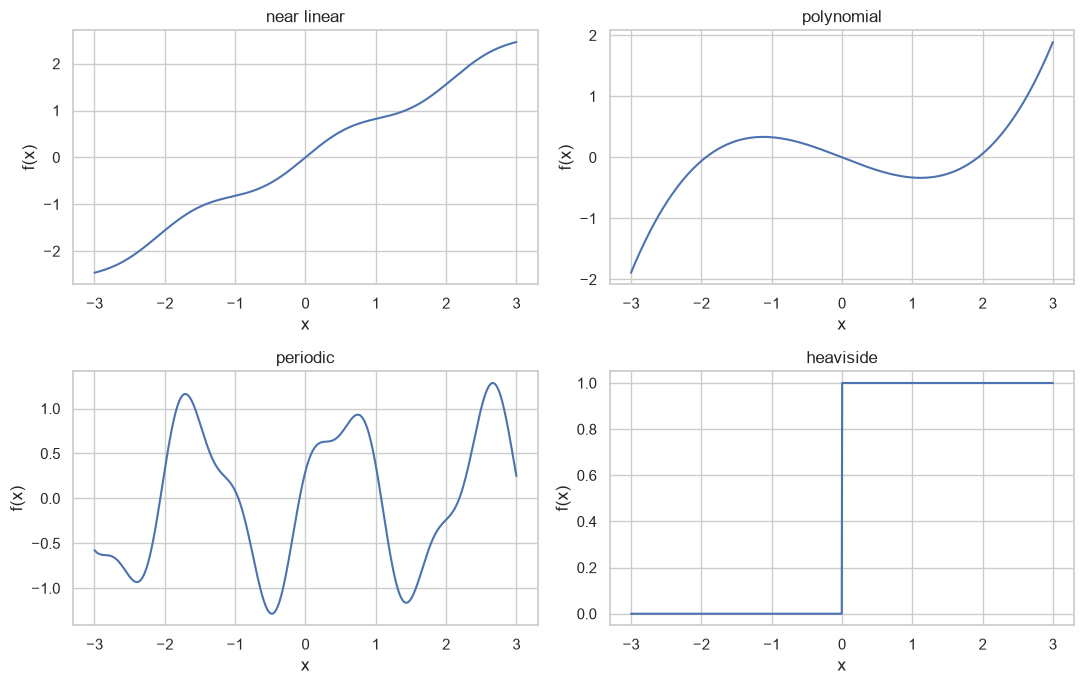

In [21]:
x_plot = np.linspace(-3, 3, 1000, dtype=np.float32)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, function) in zip(axes.ravel(), FUNCTIONS.items()):
    ax.plot(x_plot, function(x_plot))
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "synthetic_functions.png", dpi=170, bbox_inches="tight")
plt.show()


In [22]:
class RegressionMLP(nn.Module):
    def __init__(self, depth, width):
        super().__init__()
        layers = []
        in_features = 1

        for _ in range(depth):
            linear = nn.Linear(in_features, width)
            nn.init.xavier_uniform_(
                linear.weight,
                gain=nn.init.calculate_gain("tanh"),
            )
            nn.init.zeros_(linear.bias)
            layers.extend([linear, nn.Tanh()])
            in_features = width

        output = nn.Linear(in_features, 1)
        nn.init.xavier_uniform_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_data(function, n_train=500, n_val=250, noise=0.06):
    rng = np.random.default_rng(SEED)
    x = rng.uniform(-3, 3, size=n_train + n_val).astype(np.float32)
    y = function(x).astype(np.float32) + rng.normal(0, noise, size=len(x)).astype(np.float32)

    order = rng.permutation(len(x))
    train_idx, val_idx = order[:n_train], order[n_train:]
    x_test = np.linspace(-3, 3, 1000, dtype=np.float32)

    return (
        torch.from_numpy(x[train_idx, None]).to(DEVICE),
        torch.from_numpy(y[train_idx, None]).to(DEVICE),
        torch.from_numpy(x[val_idx, None]).to(DEVICE),
        torch.from_numpy(y[val_idx, None]).to(DEVICE),
        torch.from_numpy(x_test[:, None]).to(DEVICE),
        torch.from_numpy(function(x_test)[:, None].astype(np.float32)).to(DEVICE),
    )


def fit_regressor(function, depth, width, epochs=EPOCHS):
    set_seed()
    X_train, y_train, X_val, y_val, X_test, y_test = make_data(function)
    model = RegressionMLP(depth, width).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        train_prediction = model(X_train)
        train_loss = loss_fn(train_prediction, y_train)
        train_loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % 20 == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_val), y_val).item()
            history.append({
                "epoch": epoch,
                "train_mse": train_loss.item(),
                "val_mse": val_loss,
            })

    model.eval()
    with torch.no_grad():
        prediction = model(X_test).cpu().numpy().ravel()
        test_mse = loss_fn(model(X_test), y_test).item()

    return model, pd.DataFrame(history), X_test.cpu().numpy().ravel(), prediction, test_mse

## Heatmap width × depth для всех функций

Одинаковую сетку `depth × width` прогоняю для каждой из четырех функций.


In [23]:
synthetic_grid = []

for function_name, function in FUNCTIONS.items():
    print(f"\n### {function_name}")
    for depth in DEPTHS:
        for width in WIDTHS:
            print(f"depth={depth}, width={width}")
            model, history, x_test, prediction, test_mse = fit_regressor(
                function, depth, width
            )
            synthetic_grid.append({
                "function": function_name,
                "depth": depth,
                "width": width,
                "parameters": count_parameters(model),
                "test_mse": test_mse,
            })
            del model, history, x_test, prediction
            gc.collect()

synthetic_grid = pd.DataFrame(synthetic_grid)
synthetic_grid.to_csv(OUTPUT_DIR / "synthetic_grid_results.csv", index=False)

synthetic_grid.sort_values(["function", "test_mse"]).groupby("function").head(5)


### near linear
depth=1, width=8
depth=1, width=16
depth=1, width=32
depth=1, width=64
depth=1, width=128
depth=1, width=256
depth=2, width=8
depth=2, width=16
depth=2, width=32
depth=2, width=64
depth=2, width=128
depth=2, width=256
depth=5, width=8
depth=5, width=16
depth=5, width=32
depth=5, width=64
depth=5, width=128
depth=5, width=256
depth=10, width=8
depth=10, width=16
depth=10, width=32
depth=10, width=64
depth=10, width=128
depth=10, width=256
depth=20, width=8
depth=20, width=16
depth=20, width=32
depth=20, width=64
depth=20, width=128
depth=20, width=256
depth=30, width=8
depth=30, width=16
depth=30, width=32
depth=30, width=64
depth=30, width=128
depth=30, width=256
depth=50, width=8
depth=50, width=16
depth=50, width=32
depth=50, width=64
depth=50, width=128
depth=50, width=256

### polynomial
depth=1, width=8
depth=1, width=16
depth=1, width=32
depth=1, width=64
depth=1, width=128
depth=1, width=256
depth=2, width=8
depth=2, width=16
depth=2, width=32
depth=2, width=64


,function,depth,width,parameters,test_mse
156,heaviside,30,8,2113,0.000092
159,heaviside,30,64,120833,0.000198
149,heaviside,10,256,592897,0.000379
147,heaviside,10,64,37633,0.000545
153,heaviside,20,64,79233,0.000591
13,near linear,5,16,1137,0.000064
15,near linear,5,64,16833,0.000099
16,near linear,5,128,66433,0.000111
18,near linear,10,8,673,0.000130
14,near linear,5,32,4321,0.000193


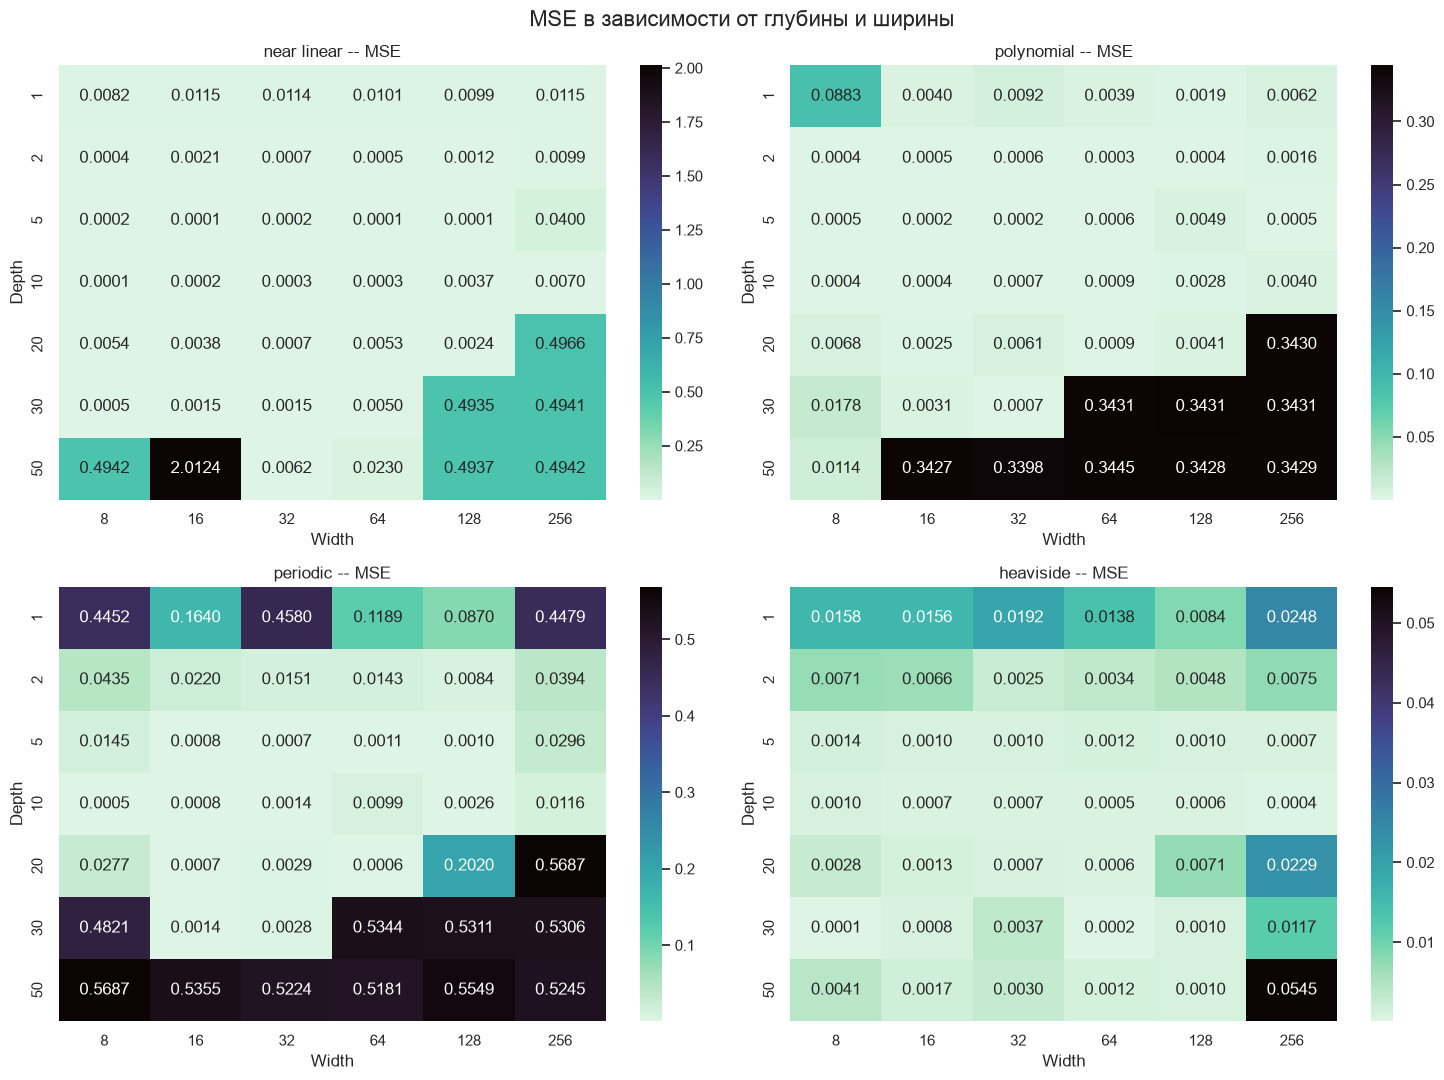

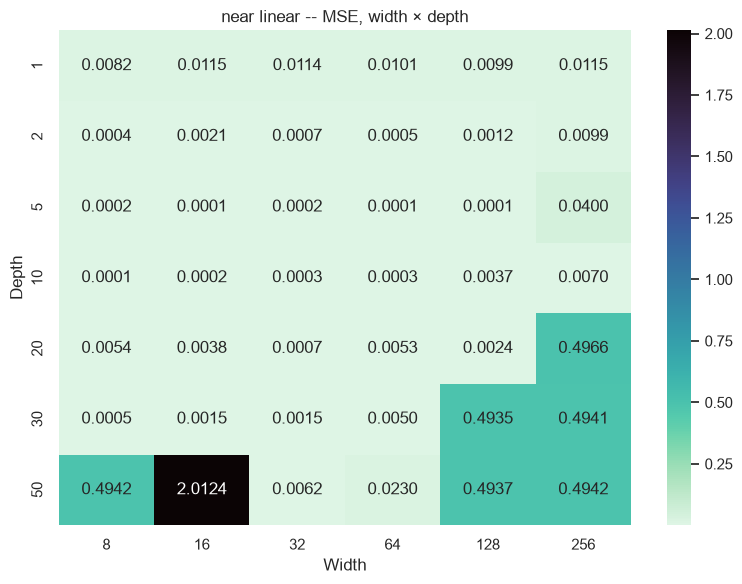

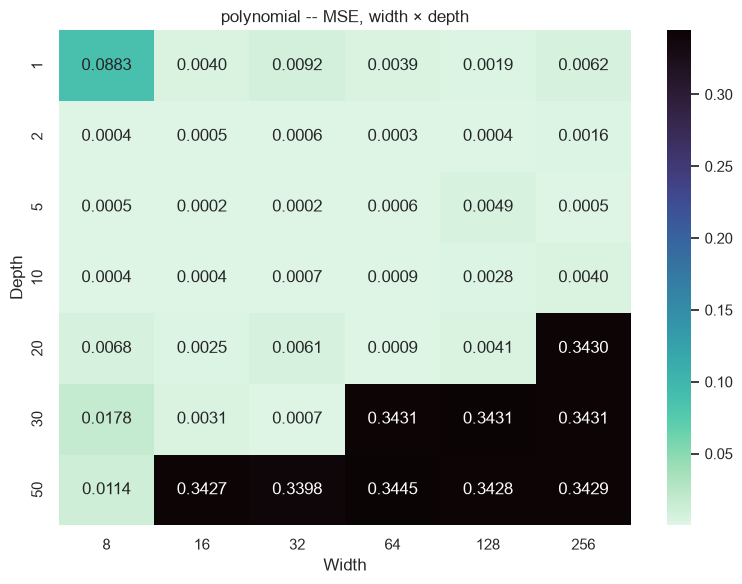

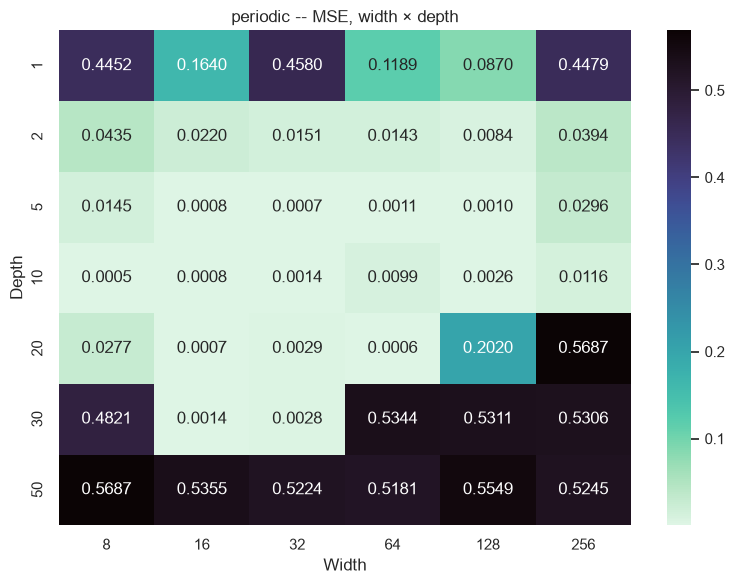

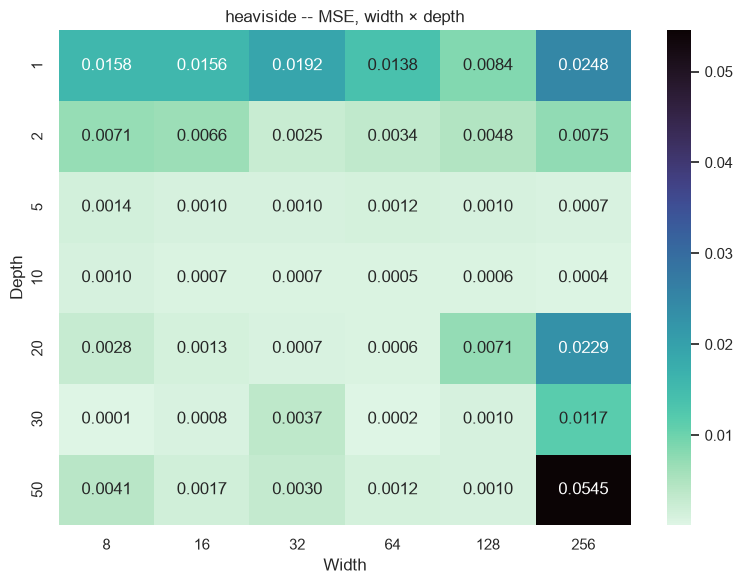

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, function_name in zip(axes.ravel(), FUNCTIONS):
    function_results = synthetic_grid[
        synthetic_grid["function"] == function_name
    ]
    mse_heatmap = function_results.pivot(
        index="depth",
        columns="width",
        values="test_mse",
    )

    sns.heatmap(
        mse_heatmap,
        annot=True,
        fmt=".4f",
        cmap="mako_r",
        ax=ax,
    )
    ax.set_title(f"{function_name} -- MSE")
    ax.set_xlabel("Width")
    ax.set_ylabel("Depth")

plt.suptitle("MSE в зависимости от глубины и ширины", fontsize=16)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "synthetic_mse_heatmaps_all.png",
    dpi=170,
    bbox_inches="tight",
)
plt.show()

for function_name in FUNCTIONS:
    function_results = synthetic_grid[
        synthetic_grid["function"] == function_name
    ]
    mse_heatmap = function_results.pivot(
        index="depth",
        columns="width",
        values="test_mse",
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(mse_heatmap, annot=True, fmt=".4f", cmap="mako_r")
    plt.title(f"{function_name} -- MSE, width × depth")
    plt.xlabel("Width")
    plt.ylabel("Depth")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"synthetic_mse_heatmap_{function_name}.png",
        dpi=170,
        bbox_inches="tight",
    )
    plt.show()

Тут уже стоит добавить пару слоев хотя бы, в отличие от предыдущих экспериментов. Тем не менее, бесконечное увеличение их количества все еще не панацея.

## Shallow vs deep на четырех функциях


In [25]:
COMPARE_CONFIGS = [(1, 128), (5, 64), (20, 32)]
comparison_rows = []
comparison_predictions = {}
comparison_histories = {}

for function_name, function in FUNCTIONS.items():
    for depth, width in COMPARE_CONFIGS:
        model, history, x_test, prediction, test_mse = fit_regressor(function, depth, width)
        comparison_rows.append({
            "function": function_name,
            "depth": depth,
            "width": width,
            "parameters": count_parameters(model),
            "test_mse": test_mse,
        })
        comparison_predictions[(function_name, depth, width)] = (x_test, prediction)
        comparison_histories[(function_name, depth, width)] = history
        del model
        gc.collect()

comparison_results = pd.DataFrame(comparison_rows)
comparison_results.to_csv(OUTPUT_DIR / "synthetic_comparison.csv", index=False)
comparison_results


,function,depth,width,parameters,test_mse
0,near linear,1,128,385,0.009892
1,near linear,5,64,16833,0.000099
2,near linear,20,32,20161,0.000738
3,polynomial,1,128,385,0.001940
4,polynomial,5,64,16833,0.000636
5,polynomial,20,32,20161,0.006127
6,periodic,1,128,385,0.087001
7,periodic,5,64,16833,0.001113
8,periodic,20,32,20161,0.002903
9,heaviside,1,128,385,0.008401


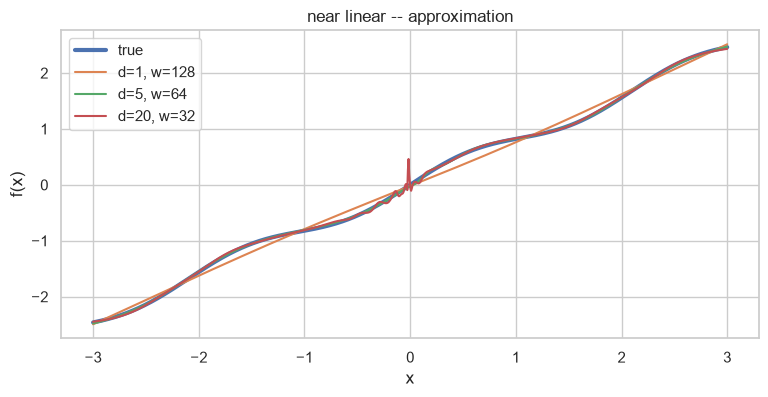

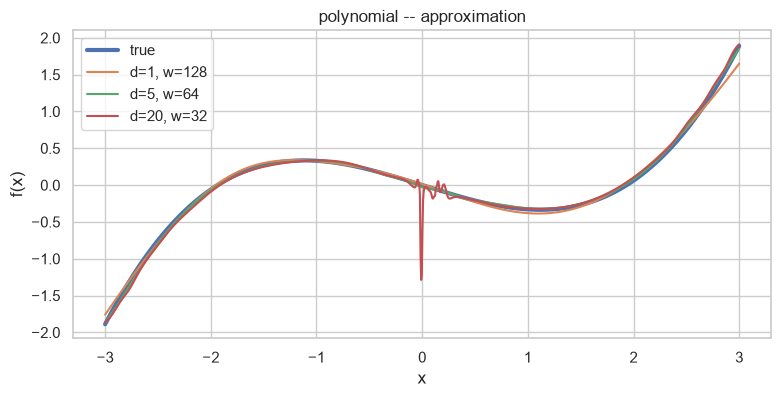

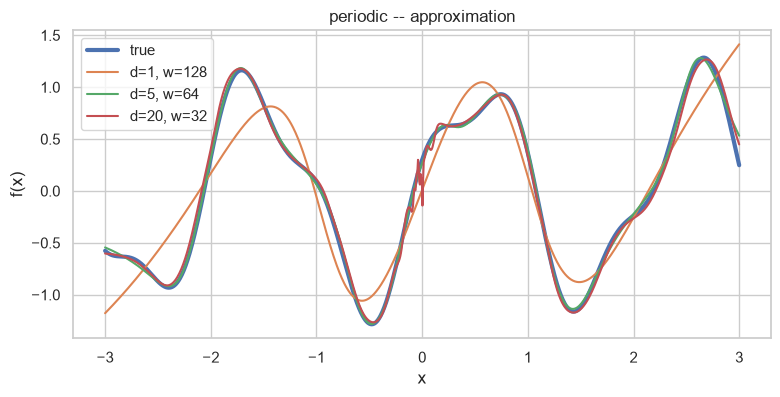

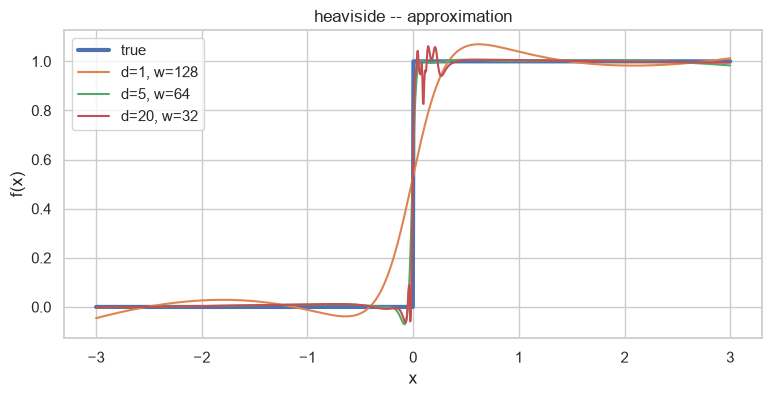

In [26]:
for function_name, function in FUNCTIONS.items():
    plt.figure(figsize=(9, 4))
    plt.plot(x_plot, function(x_plot), linewidth=3, label="true")
    for depth, width in COMPARE_CONFIGS:
        x_test, prediction = comparison_predictions[(function_name, depth, width)]
        plt.plot(x_test, prediction, label=f"d={depth}, w={width}")
    plt.title(f"{function_name} -- approximation")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.savefig(OUTPUT_DIR / f"synthetic_approximation_{function_name}.png", dpi=170, bbox_inches="tight")
    plt.show()


Видим, что слишком глубокие сети зачастую слишком сложные, неглубокая же -- наоборот, слишком простая.

## Learning curve

На примере периодической функции.

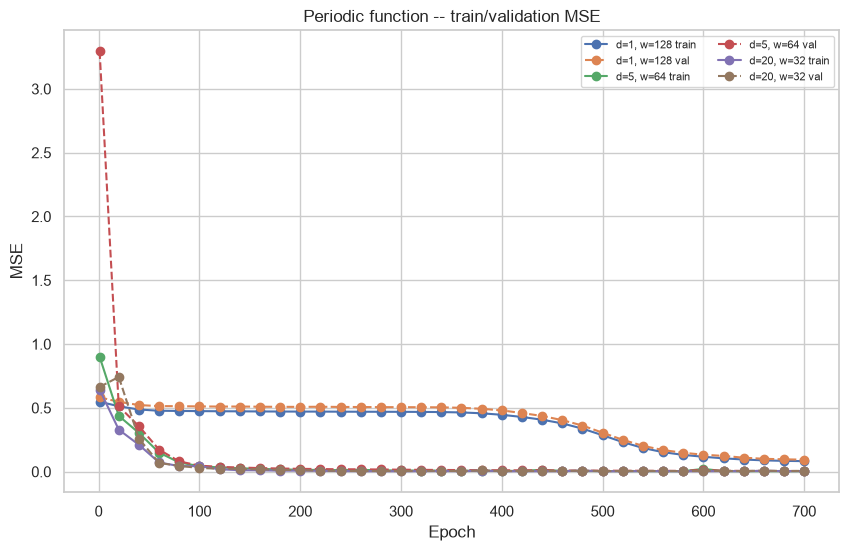

In [27]:
plt.figure(figsize=(10, 6))
for depth, width in COMPARE_CONFIGS:
    history = comparison_histories[("periodic", depth, width)]
    plt.plot(history.epoch, history.train_mse, marker="o", label=f"d={depth}, w={width} train")
    plt.plot(history.epoch, history.val_mse, marker="o", linestyle="--", label=f"d={depth}, w={width} val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Periodic function -- train/validation MSE")
plt.legend(ncol=2, fontsize=8)
plt.savefig(OUTPUT_DIR / "synthetic_learning_curve.png", dpi=170, bbox_inches="tight")
plt.show()


Более глубокие сети быстрее достигли плато минимума.

## Выводы

Были исследованы сети для различных видов функций:

- почти линейная функция проверяет, что сложность действительно лишняя там, где задача простая;
- полином показывает гладкую нелинейность;
- периодическая функция дает задачу с локальными осцилляциями;
- Heaviside показывает качественно другой случай: сеть может сжать переход в узкую область, но непрерывная MLP не может идеально воспроизвести сам скачок в sup-норме;
- heatmap теперь строится для всех четырех функций; видно, что оптимальная глубина/ширина **зависит от структуры функции**.

Очень глубокая сеть сама по себе ничего не гарантирует -- оптимизировать ее еще надо. В то же время недостаточно глубокая сеть не сможет хорошо подстроиться под сложные функции.
